In [18]:
%load_ext watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tcspc_sim import SimSample, SimFalcon, PhasorPlot
%watermark -v -p matplotlib,numpy

Python implementation: CPython
Python version       : 3.7.4
IPython version      : 7.20.0

matplotlib: 3.3.2
numpy     : 1.19.2



In [20]:
lifetimes = [3.6, 1.8, 6.0, 1.0]
fractions = [50, 40, 50, 5]
fractionnames = ['Epac bound', 'Epac unbound', 'AF long', 'AF short']
simSample = SimSample(lifetimes, fractions, fractionnames)
print(simSample)

Sample contains the following lifetimes:
  * Epac bound : 3.60ns - 34.48% of photons
  * Epac unbound : 1.80ns - 27.59% of photons
  * AF long : 6.00ns - 34.48% of photons
  * AF short : 1.00ns - 3.45% of photons


In [21]:
qv = [0.15, 0.525,0, 0]
simSample.set_quenching(qv)
print(simSample)

Sample contains the following lifetimes:
  * Epac bound : 3.06ns - 36.48% of photons
  * Epac unbound : 0.85ns - 16.31% of photons
  * AF long : 6.00ns - 42.92% of photons
  * AF short : 1.00ns - 4.29% of photons


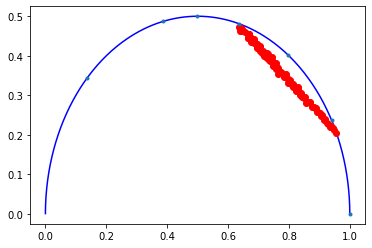

In [29]:
fraction = np.linspace(0,100,101)
simFalcon = SimFalcon([0])
x_coords = []
y_coords = []


for f in fraction:
    fractions = [f, 100-f, 0, 5]
    simSample.set_fraction(fractions, qv)
    photons,npht = simSample.generate_photons(5e3)
    simFalcon.setphotons(photons)
    x,y = simFalcon.getphasorcoordinates()
    x_coords.append(x)
    y_coords.append(y)

phasorPlot = PhasorPlot(simFalcon.getomega(),np.array([0,1,2,3,4,5,10]))
phasorPlot.plot(x_coords,y_coords)